In [23]:
%load_ext autoreload
%autoreload 2

import numpy  as np
import pandas as pd
import h5py
from pathlib import Path

from astropy    import units as u
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'

font = {'family' : 'sans-serif',
        'size'   : 8}

matplotlib.rc('font', **font)

from scipy.interpolate import RegularGridInterpolator
from scipy.signal      import argrelextrema

from common import hallmark as hm
from common import mockservation as mk
from common import dalt
from common import viz
from common import io_raptor as io

import plotscripts
from plotscripts import subtract, image2d, loadfigure, getimagedata

import rapplot

from module import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load paths to images

In [2]:
# Load all images 
pf = hm.ParaFrame('cache/{mag}a{aspin:g}_w{window:d}/Rh{Rhigh:d}_i{inc:d}/n{n:n}/img_data_{snapshot:d}.h5')
sel = pf(snapshot=[999, 1000, 101000])
display(sel)

,path,mag,aspin,window,Rhigh,inc,n,snapshot
0,cache/Ma101_w1/Rh1_i15/n0/img_data_999.h5,M,101.0,1,1,15,0,999
1,cache/Ma101_w1/Rh1_i15/n1/img_data_1000.h5,M,101.0,1,1,15,1,1000
2,cache/Ma101_w1/Rh1_i15/n1/img_data_101000.h5,M,101.0,1,1,15,1,101000
3,cache/Ma101_w1/Rh1_i15/n1/img_data_999.h5,M,101.0,1,1,15,1,999
4,cache/Ma101_w1/Rh1_i15/n100/img_data_999.h5,M,101.0,1,1,15,100,999
5,cache/Ma101_w1/Rh1_i15/n2/img_data_1000.h5,M,101.0,1,1,15,2,1000
6,cache/Ma101_w1/Rh1_i15/n2/img_data_101000.h5,M,101.0,1,1,15,2,101000
7,cache/Ma101_w1/Rh1_i15/n2/img_data_999.h5,M,101.0,1,1,15,2,999
8,cache/Ma101_w1/Rh1_i30/n0/img_data_999.h5,M,101.0,1,1,30,0,999
9,cache/Ma101_w1/Rh1_i30/n1/img_data_1000.h5,M,101.0,1,1,30,1,1000


In [3]:
ns = [100, 0, 1,2]
incs = np.sort(np.array(sel.inc.unique())) 

## Create a mask 

In [4]:
#get critical curve 
alpha1, beta1 = import_ab(1.01, 15, True) 
# alpha1

In [5]:
N = 1000
xmin, xmax = -20, 20

x = np.linspace(xmin, xmax, N)
y = np.linspace(xmin, xmax, N)

X, Y = np.meshgrid(x, y)

In [6]:
valid = np.isfinite(alpha1) & np.isfinite(beta1)
alpha = alpha1[valid]
beta  = beta1[valid]

In [7]:
from matplotlib.path import Path
curve = Path(np.column_stack((alpha, beta)))
points = np.column_stack((X.ravel(), Y.ravel()))

# TODO: optimize 
mask = curve.contains_points(points).reshape(N, N)

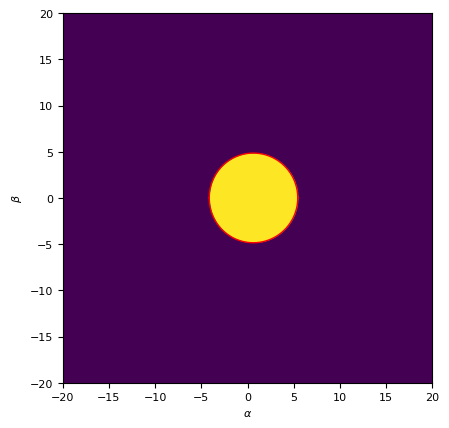

In [8]:
plt.imshow(mask, extent=[-20, 20, -20, 20], origin='lower')
plt.plot(alpha1, beta1, 'r-', lw=1)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')
plt.show()

## Apply mask to images 

In [9]:
inc = 15 
n = 1


from pathlib import Path
s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 101000)]
path_object = Path(s.path.item())
img_path = str(path_object.parent)
img_path

'cache/Ma101_w1/Rh1_i15/n1'

Reading in:  cache/Ma101_w1/Rh1_i15/n1/img_data_1000.h5
8


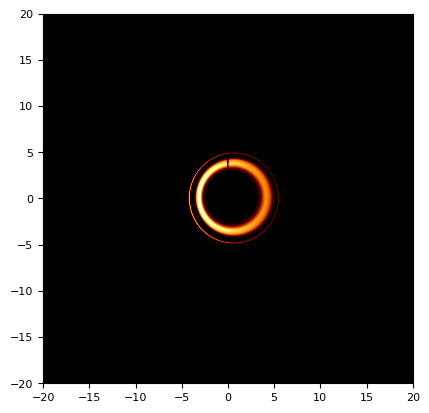

In [10]:
fig, ax = plt.subplots(1, 1)
data_id_all, min, max, image_array = getimagedata(img_path, 1000)
figure = loadfigure(image_array, np.min(image_array), np.max(image_array), fig, ax, 20, 1, label="Stokes", cmap="afmhot")


In [11]:
print("masking inner region to be 0")
oimg = image_array.copy()
oimg[mask] = 0

masking inner region to be 0


In [12]:
print("masking outer region to be 0")
iimg = image_array.copy()
iimg[~mask] = 0

masking outer region to be 0


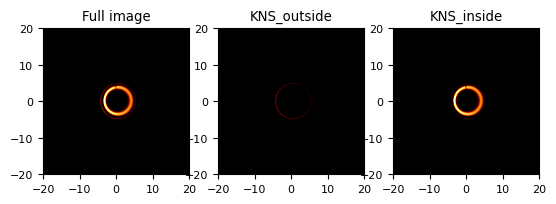

In [13]:

fig, axes = plt.subplots(1, 3)

im1 = loadfigure(image_array, np.min(image_array), np.max(image_array), fig, axes[0], 20, 1, label="Full image", cmap="afmhot")
im2 = loadfigure(oimg, np.min(oimg), np.max(oimg), fig, axes[1], 20, 1, label="KNS_outside", cmap="afmhot")
im3 = loadfigure(iimg, np.min(iimg), np.max(iimg), fig, axes[2], 20, 1, label="KNS_inside", cmap="afmhot")

axes[0].set_title("Full image")
axes[1].set_title("KNS_outside")
axes[2].set_title("KNS_inside")

fig.savefig(f"output/plot/fig_inout_i{inc}.pdf")

In [24]:
from pathlib import Path

# mask out inner region. BH 
mov_omask = io.load_mov(s.path, [1000], 20, mask= mask, resize = False)

# mask out outer region. NKS - BH
mov_imask = io.load_mov(s.path,[1000], 20, mask= ~mask, resize = False)

# original image
mov = io.load_mov(s.path, [1000], 20, mask=None, resize = False)

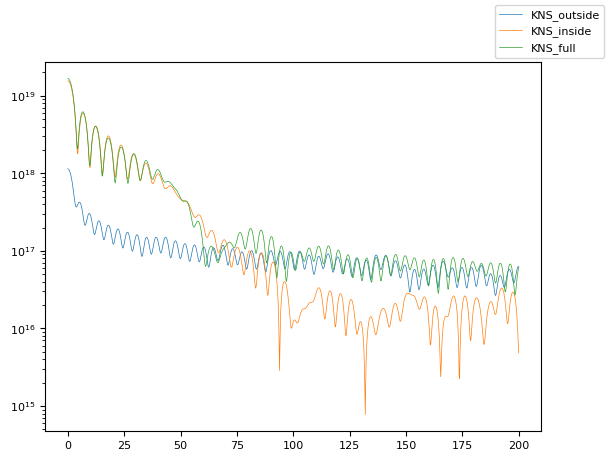

In [25]:
fig, axes = plt.subplots(1, 1)

h1 = plot_va(mov_omask, axes, n, i=45)[0]
h2 = plot_va(mov_imask, axes, n, i=45)[0]
h3 = plot_va(mov, axes, n, i=45)[0]

h1.set_label("KNS_outside")
h2.set_label("KNS_inside")
h3.set_label("KNS_full")

# axes.set_xlim(0,100) 
fig.legend(loc='upper right')

fig.savefig(f"output/plot/va_inout_i{inc}.pdf")


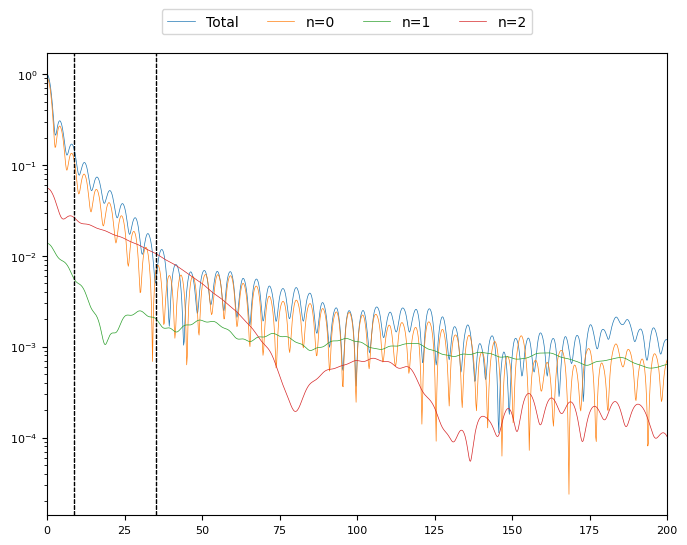

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharey=True, sharex=True)

inc = 15
i = 0

legend_handles = []  

for col, n in enumerate(ns): 
    if n in [1, 2]: 
        s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 1000)]
        path_object = Path(s.path.item())
        mov_omask = io.load_mov(s.path, [1000], 20, mask= mask, resize = True)
 
    else: 
        s = sel[(sel['inc'] == inc) & (sel['n'] == n) & (sel['snapshot'] == 999)]
        path_object = Path(s.path.item())
        mov_omask = io.load_mov(s.path, [900], 20, mask= mask, resize = True)
    
    # Plot VA
    handles = plot_va(mov_omask, ax, n, i)
    legend_handles.extend(handles) 
    
    # add lines for EHT, BHEX 
    ax.axvline(x=8.6, color='black', linestyle='--', lw=0.8)
    ax.axvline(x=35, color='black', linestyle='--', lw=0.8)
    
    ax.set_xlim(0,200)
    

fig.legend(
    handles=legend_handles[0:4],
    fontsize=10,
    ncol=4,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.9),
    frameon=True
)

fig.savefig(f"output/plot/va_all_i{inc}.pdf")
